# Climate Change in Glacier National Park

In [47]:
### import libraries

### save interactive plots
!pip install holoviews
import holoviews as hv

### make interactive plots
!pip install hvplot
import hvplot.pandas

### work with tabular data
import pandas as pd

### create visualizations
import matplotlib as plt

### common statistical plots for tabular data
!pip install seaborn
import seaborn as sns

### fit an OLS linear regression
!pip install scikit-learn
from sklearn.linear_model import LinearRegression

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 31.9 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [14]:
### load climate data from NCEI
ncei_url = (
    'https://www.ncei.noaa.gov/access/services/data/v1?'
    'dataset=daily-summaries&'
    'dataTypes=TMAX&'
    'stations=USC00244558&'
    'startDate=1897-01-01&'
    'endDate=2020-01-01&'
    'units=standard')

glacier_data = pd.read_csv(
    
    ncei_url, 

    ### use date column as index
    index_col='DATE',
    
    ### tell python to treat DATE as date
    parse_dates = True)

glacier_data.head()


,STATION,TMAX
DATE,,
1897-01-01,USC00244558,41.0
1897-01-02,USC00244558,38.0
1897-01-03,USC00244558,28.0
1897-01-04,USC00244558,NaN
1897-01-05,USC00244558,NaN


In [15]:
### select TMAX data column for dataframe
temp_df = glacier_data[['TMAX']]
temp_df

,TMAX
DATE,
1897-01-01,41.0
1897-01-02,38.0
1897-01-03,28.0
1897-01-04,NaN
1897-01-05,NaN
...,...
2019-12-28,28.0
2019-12-29,30.0
2019-12-30,27.0


In [19]:
### rename TMAX column
temp_units_df = temp_df.rename(columns={
    'TMAX':'max_temp_f'
})

In [20]:
### convert fahrenheit to celsius using conversion equation
temp_units_df['max_temp_c']=(temp_units_df['max_temp_f']-32)*5/9
temp_units_df

,max_temp_f,max_temp_c
DATE,,
1897-01-01,41.0,5.000000
1897-01-02,38.0,3.333333
1897-01-03,28.0,-2.222222
1897-01-04,NaN,NaN
1897-01-05,NaN,NaN
...,...,...
2019-12-28,28.0,-2.222222
2019-12-29,30.0,-1.111111
2019-12-30,27.0,-2.777778


<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_25718/436310978.py:6: SyntaxWarning: invalid escape sequence '\c'
  ylabel = 'Temperature ($^\circ$C)',


<Axes: title={'center': 'Daily maximum temperature in Glacier National Park'}, xlabel='Date', ylabel='Temperature ($^\\circ$C)'>

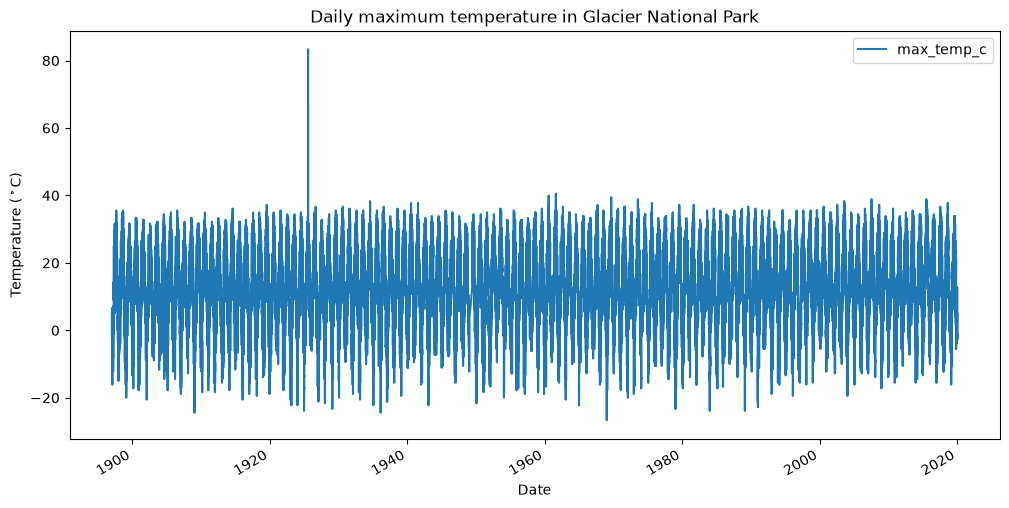

In [22]:
### plot data
temp_units_df.plot(
    y = 'max_temp_c',
    title = 'Daily maximum temperature in Glacier National Park',
    xlabel = 'Date',
    ylabel = 'Temperature ($^\circ$C)',
    figsize = (12,6))

In [23]:
### get mean annual maximum temp
ann_temp_df = (

    ### resample df
    temp_units_df

    ### sample annually
    .resample('YS')

    ### take mean
    .mean()
)

ann_temp_df

,max_temp_f,max_temp_c
DATE,,
1897-01-01,55.431818,13.017677
1898-01-01,55.298630,12.943683
1899-01-01,50.832418,10.462454
1900-01-01,54.627397,12.570776
1901-01-01,53.583562,11.990868
...,...,...
2016-01-01,57.128415,13.960231
2017-01-01,55.482192,13.045662
2018-01-01,55.983425,13.324125


<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_25718/3657973231.py:6: SyntaxWarning: invalid escape sequence '\c'
  ylabel = 'Temperature ($^\circ$C)'


<Axes: title={'center': 'Mean annual maximum temperature in Glacier National Park'}, xlabel='Year', ylabel='Temperature ($^\\circ$C)'>

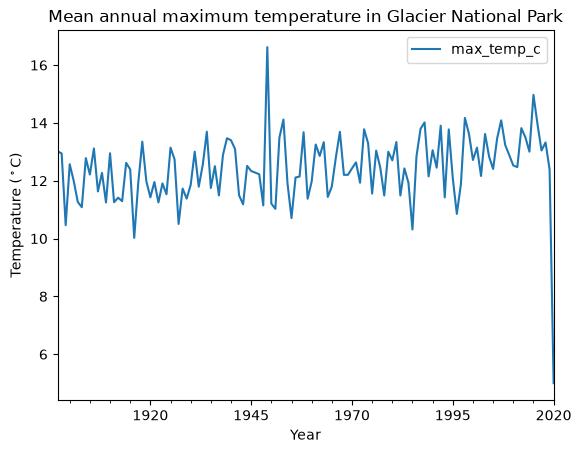

In [25]:
### plot annual maximum temperature
ann_temp_df.plot(
    y = 'max_temp_c',
    title = 'Mean annual maximum temperature in Glacier National Park',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)

In [27]:
### investigate 2020 dip
temp_units_df.loc['2020'].describe()

,max_temp_f,max_temp_c
count,1.0,1.0
mean,41.0,5.0
std,NaN,NaN
min,41.0,5.0
25%,41.0,5.0
50%,41.0,5.0
75%,41.0,5.0
max,41.0,5.0


In [36]:
### remove 2020 since there is only one observation
ann_temp_df=ann_temp_df.drop(ann_temp_df.index[-1])

ann_temp_df.tail()

,max_temp_f,max_temp_c
DATE,,
2015-01-01,58.947945,14.971081
2016-01-01,57.128415,13.960231
2017-01-01,55.482192,13.045662
2018-01-01,55.983425,13.324125
2019-01-01,54.304110,12.391172


In [38]:
hvplot.extension('bokeh')

In [40]:
### make interactive plot
ann_temp_plot = ann_temp_df.hvplot(
    y = 'max_temp_c',
    title = 'Mean annual maximum temperature in Glacier National Park',
    xlabel='Year',
    ylabel='Temperature (degrees Celsius)'
)

ann_temp_plot

:Curve   [DATE]   (max_temp_c)

In [41]:
### save plot
hv.save(ann_temp_plot, 'annual_temp_glacier.html')

In [43]:
### subset data to just include celsius
ann_temp_c_df = ann_temp_df[['max_temp_c']]

ann_temp_c_df

,max_temp_c
DATE,
1897-01-01,13.017677
1898-01-01,12.943683
1899-01-01,10.462454
1900-01-01,12.570776
1901-01-01,11.990868
...,...
2015-01-01,14.971081
2016-01-01,13.960231
2017-01-01,13.045662


In [49]:
### fit an OLS linear regression to the data

### define independent variable
### reshape year to be a 2d array for scikit learn
ind_variable = ann_temp_c_df.index.year.values.reshape(-1,1)

### define dependent variable
dep_variable = ann_temp_c_df

### make linear regression model
model = LinearRegression()

### fit the model on the data
model.fit(ind_variable, dep_variable)

### calculate and print metrics
print(f'Slope: {model.coef_[0]} degrees Celsius per year')

Slope: [0.01064925] degrees Celsius per year


<>:17: SyntaxWarning: invalid escape sequence '\c'
<>:17: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_25718/111387361.py:17: SyntaxWarning: invalid escape sequence '\c'
  ylabel = 'Temperature ($^\circ$C)'


[Text(0.5, 1.0, 'Mean annual maximum temperature over time in Glacier National Park'),
 Text(0.5, 0, 'Year'),
 Text(0, 0.5, 'Temperature ($^\\circ$C)')]

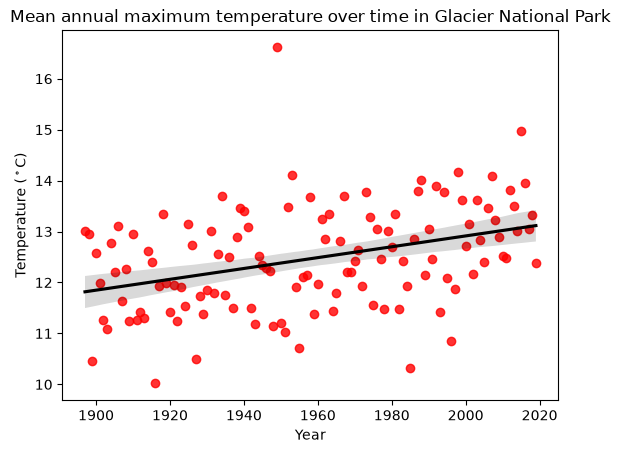

In [54]:
### plot data 
ax = sns.regplot(
    x = ann_temp_c_df.index.year, 
    y = ann_temp_c_df.max_temp_c,

    ### change color of data points
    color = 'red',

    ### change color of trend line
    line_kws = {'color':'black'}
)

### make labels
ax.set(
    title = 'Mean annual maximum temperature over time in Glacier National Park',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)
